# Preprocess of Kandy

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

## Import Data

### 2019 - 2021

In [2]:
df1 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - From 2019 to 2021 mid (with NOx).xlsx")

### 2022 - 2023

In [3]:
df2 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - From 2022-10 Oct to 2023 End (with NOx).xlsx")

### 2024

In [4]:
df3 = pd.read_excel("../Data/Data Kandy AQMS - 1 Hour - For 2024 (with NOx).xlsx")

### Combined the Dataframes

In [5]:
df_combined = pd.concat([df1,df2,df3],ignore_index=True)

#### New dataframe info

In [6]:
df_combined.shape

(35064, 19)

In [7]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  35064 non-null  datetime64[ns]
 1   Period End Time    35064 non-null  datetime64[ns]
 2   AT                 28362 non-null  float64       
 3   RH                 28356 non-null  float64       
 4   BP                 28363 non-null  float64       
 5   Solar Rad          28367 non-null  float64       
 6   Rain Gauge         28073 non-null  float64       
 7   WS Raw             27931 non-null  float64       
 8   WD Raw             28365 non-null  float64       
 9   WS Average         18027 non-null  float64       
 10  WD Average         18031 non-null  float64       
 11  O3 Conc            26782 non-null  float64       
 12  CO Conc            23788 non-null  float64       
 13  NO Conc            25946 non-null  float64       
 14  NO2 Co

In [8]:
df_combined.describe()

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,35064,35064,28362.000000,28356.000000,28363.000000,28367.000000,28073.000000,27931.000000,28365.000000,18027.000000,18031.000000,26782.000000,23788.000000,25946.000000,25905.000000,25948.000000,23659.000000,22977.000000,24091.000000
mean,2021-07-08 11:02:24.187363072,2021-07-08 12:02:24.147844096,25.861723,71.360957,954.454367,160.941920,0.178948,1.113508,196.592843,0.512215,195.797665,11.388677,652.752145,14.097119,13.030843,27.110431,1.041188,17.380859,43.971151
min,2019-01-01 00:00:00,2019-01-01 01:00:00,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.157000,-6.800000,0.000000,-1.870000,-3.780000,0.000000,0.000000
25%,2020-01-01 05:45:00,2020-01-01 06:45:00,23.200000,61.140000,953.100000,0.160000,0.000000,0.400000,162.100000,0.200000,121.450000,4.910000,455.717500,1.660000,5.900000,8.030000,0.390000,8.000000,28.000000
50%,2020-12-31 11:30:00,2020-12-31 12:30:00,25.000000,74.700000,954.400000,4.240000,0.000000,1.000000,201.200000,0.400000,208.300000,8.480000,614.900000,8.110000,11.030000,20.507500,1.040000,15.000000,40.000000
75%,2023-04-02 17:15:00,2023-04-02 18:15:00,28.300000,83.222500,955.800000,281.750000,0.000000,1.600000,227.000000,0.700000,279.400000,15.570000,790.815000,20.300000,17.280000,37.462500,1.690000,23.000000,56.000000
max,2024-12-31 23:00:00,2025-01-01 00:00:00,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,2.000000,360.000000,87.800000,9401.800000,258.450000,90.470000,348.300000,25.760000,188.000000,202.000000
std,NaN,NaN,3.396117,14.553382,1.927623,237.078795,1.418530,0.861965,40.250626,0.364607,94.126721,9.545026,338.926538,17.500552,9.642111,25.434777,1.000279,12.506621,22.575014


## Duplicates

In [9]:
df_combined.duplicated().sum()

0

No duplicates there for we don't need to do anything about it 

## Negative Values Check

In [10]:
columns_to_describe = ['O3 Conc','CO Conc', 'NO Conc', 'NO2 Conc', 'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
summary_stats = df_combined[columns_to_describe].describe()
summary_stats

,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,26782.000000,23788.000000,25946.000000,25905.000000,25948.000000,23659.000000,22977.000000,24091.000000
mean,11.388677,652.752145,14.097119,13.030843,27.110431,1.041188,17.380859,43.971151
std,9.545026,338.926538,17.500552,9.642111,25.434777,1.000279,12.506621,22.575014
min,0.000000,50.157000,-6.800000,0.000000,-1.870000,-3.780000,0.000000,0.000000
25%,4.910000,455.717500,1.660000,5.900000,8.030000,0.390000,8.000000,28.000000
50%,8.480000,614.900000,8.110000,11.030000,20.507500,1.040000,15.000000,40.000000
75%,15.570000,790.815000,20.300000,17.280000,37.462500,1.690000,23.000000,56.000000
max,87.800000,9401.800000,258.450000,90.470000,348.300000,25.760000,188.000000,202.000000


Seems to be NO, NOX, and SO2 have negative values. That is impossible because concentrations cannot be negative. It must be due to senor failure or something. I have to remove that. In this case, turning them into null and filling them is the correct way.

### Turn Negative values into Null Values

In [11]:
Negative_cols = ['NO Conc', 'NOx Conc', 'SO2 Conc']

In [12]:
for col in Negative_cols:
    if col in df_combined.columns:
        bad_count = (df_combined[col] < 0).sum()
        if bad_count > 0:
            df_combined[col] = df_combined[col].mask(df_combined[col] < 0)

In [13]:
columns_to_describe = ['O3 Conc','CO Conc', 'NO Conc', 'NO2 Conc', 'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
summary_stats = df_combined[columns_to_describe].describe()
summary_stats

,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,26782.000000,23788.000000,24714.00000,25905.000000,25848.000000,20962.000000,22977.000000,24091.000000
mean,11.388677,652.752145,14.83218,13.030843,27.218068,1.255160,17.380859,43.971151
std,9.545026,338.926538,17.61073,9.642111,25.424862,0.833361,12.506621,22.575014
min,0.000000,50.157000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.910000,455.717500,2.21000,5.900000,8.120000,0.640000,8.000000,28.000000
50%,8.480000,614.900000,8.89000,11.030000,20.645000,1.180000,15.000000,40.000000
75%,15.570000,790.815000,21.20000,17.280000,37.521750,1.780000,23.000000,56.000000
max,87.800000,9401.800000,258.45000,90.470000,348.300000,25.760000,188.000000,202.000000


## Null check

In [14]:
df_combined.isnull().sum()

Period Start Time        0
Period End Time          0
AT                    6702
RH                    6708
BP                    6701
Solar Rad             6697
Rain Gauge            6991
WS Raw                7133
WD Raw                6699
WS Average           17037
WD Average           17033
O3 Conc               8282
CO Conc              11276
NO Conc              10350
NO2 Conc              9159
NOx Conc              9216
SO2 Conc             14102
PM2.5 Conc           12087
PM10 Conc            10973
dtype: int64

In here, we don't need to drop any columns. We can fill the values

<function matplotlib.pyplot.show(close=None, block=None)>

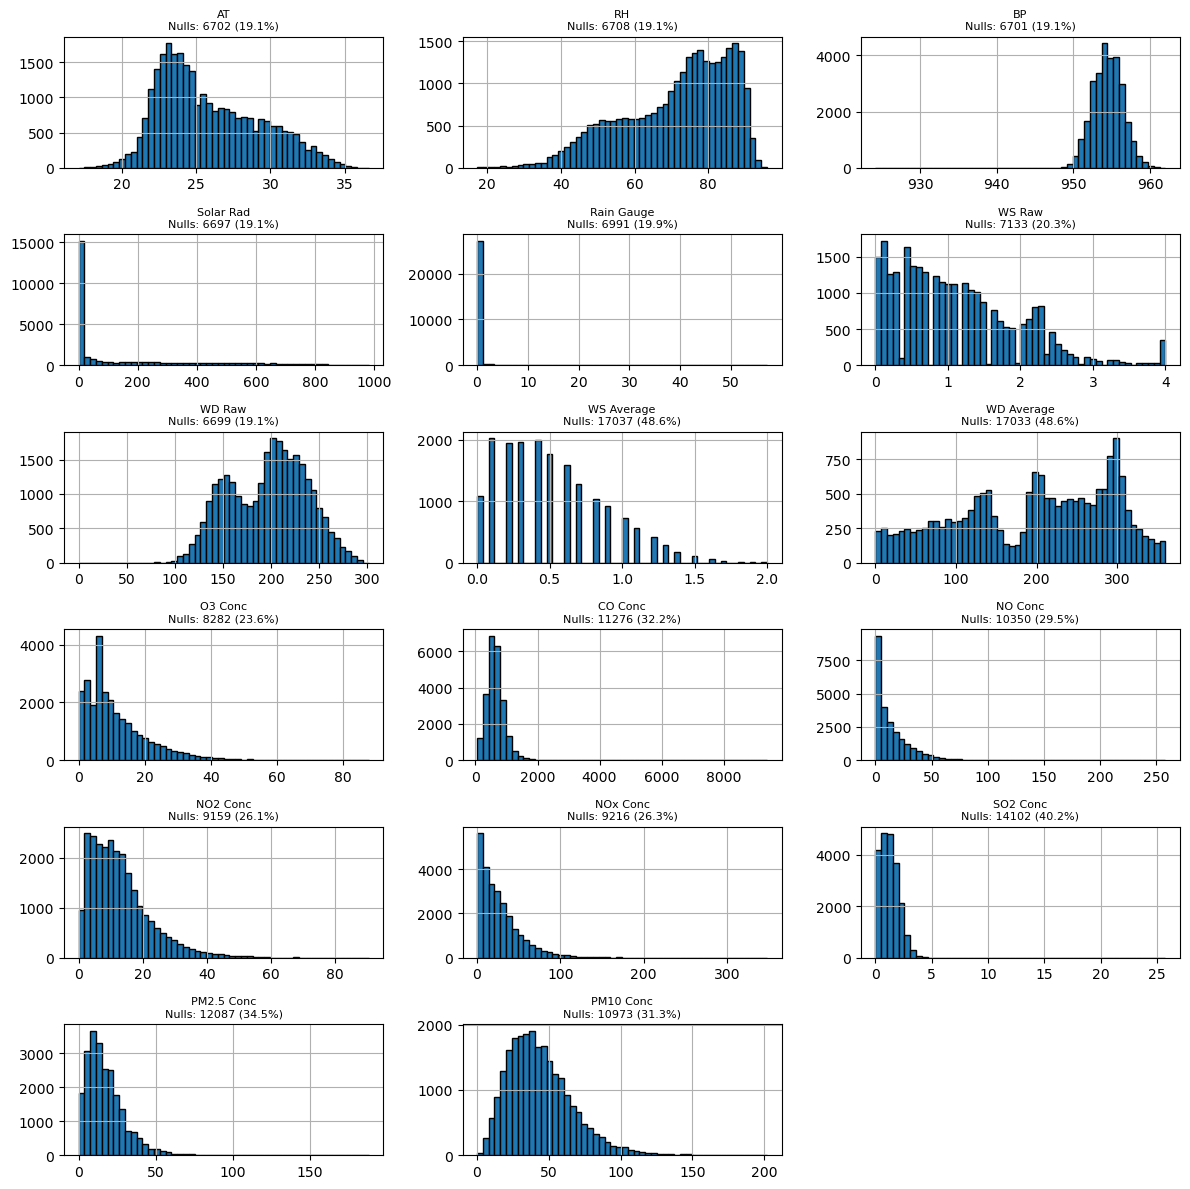

In [15]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

n_cols = 3  
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten()  # make it 1D for easy iteration

for i, col in enumerate(numeric_cols):
    df_combined[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

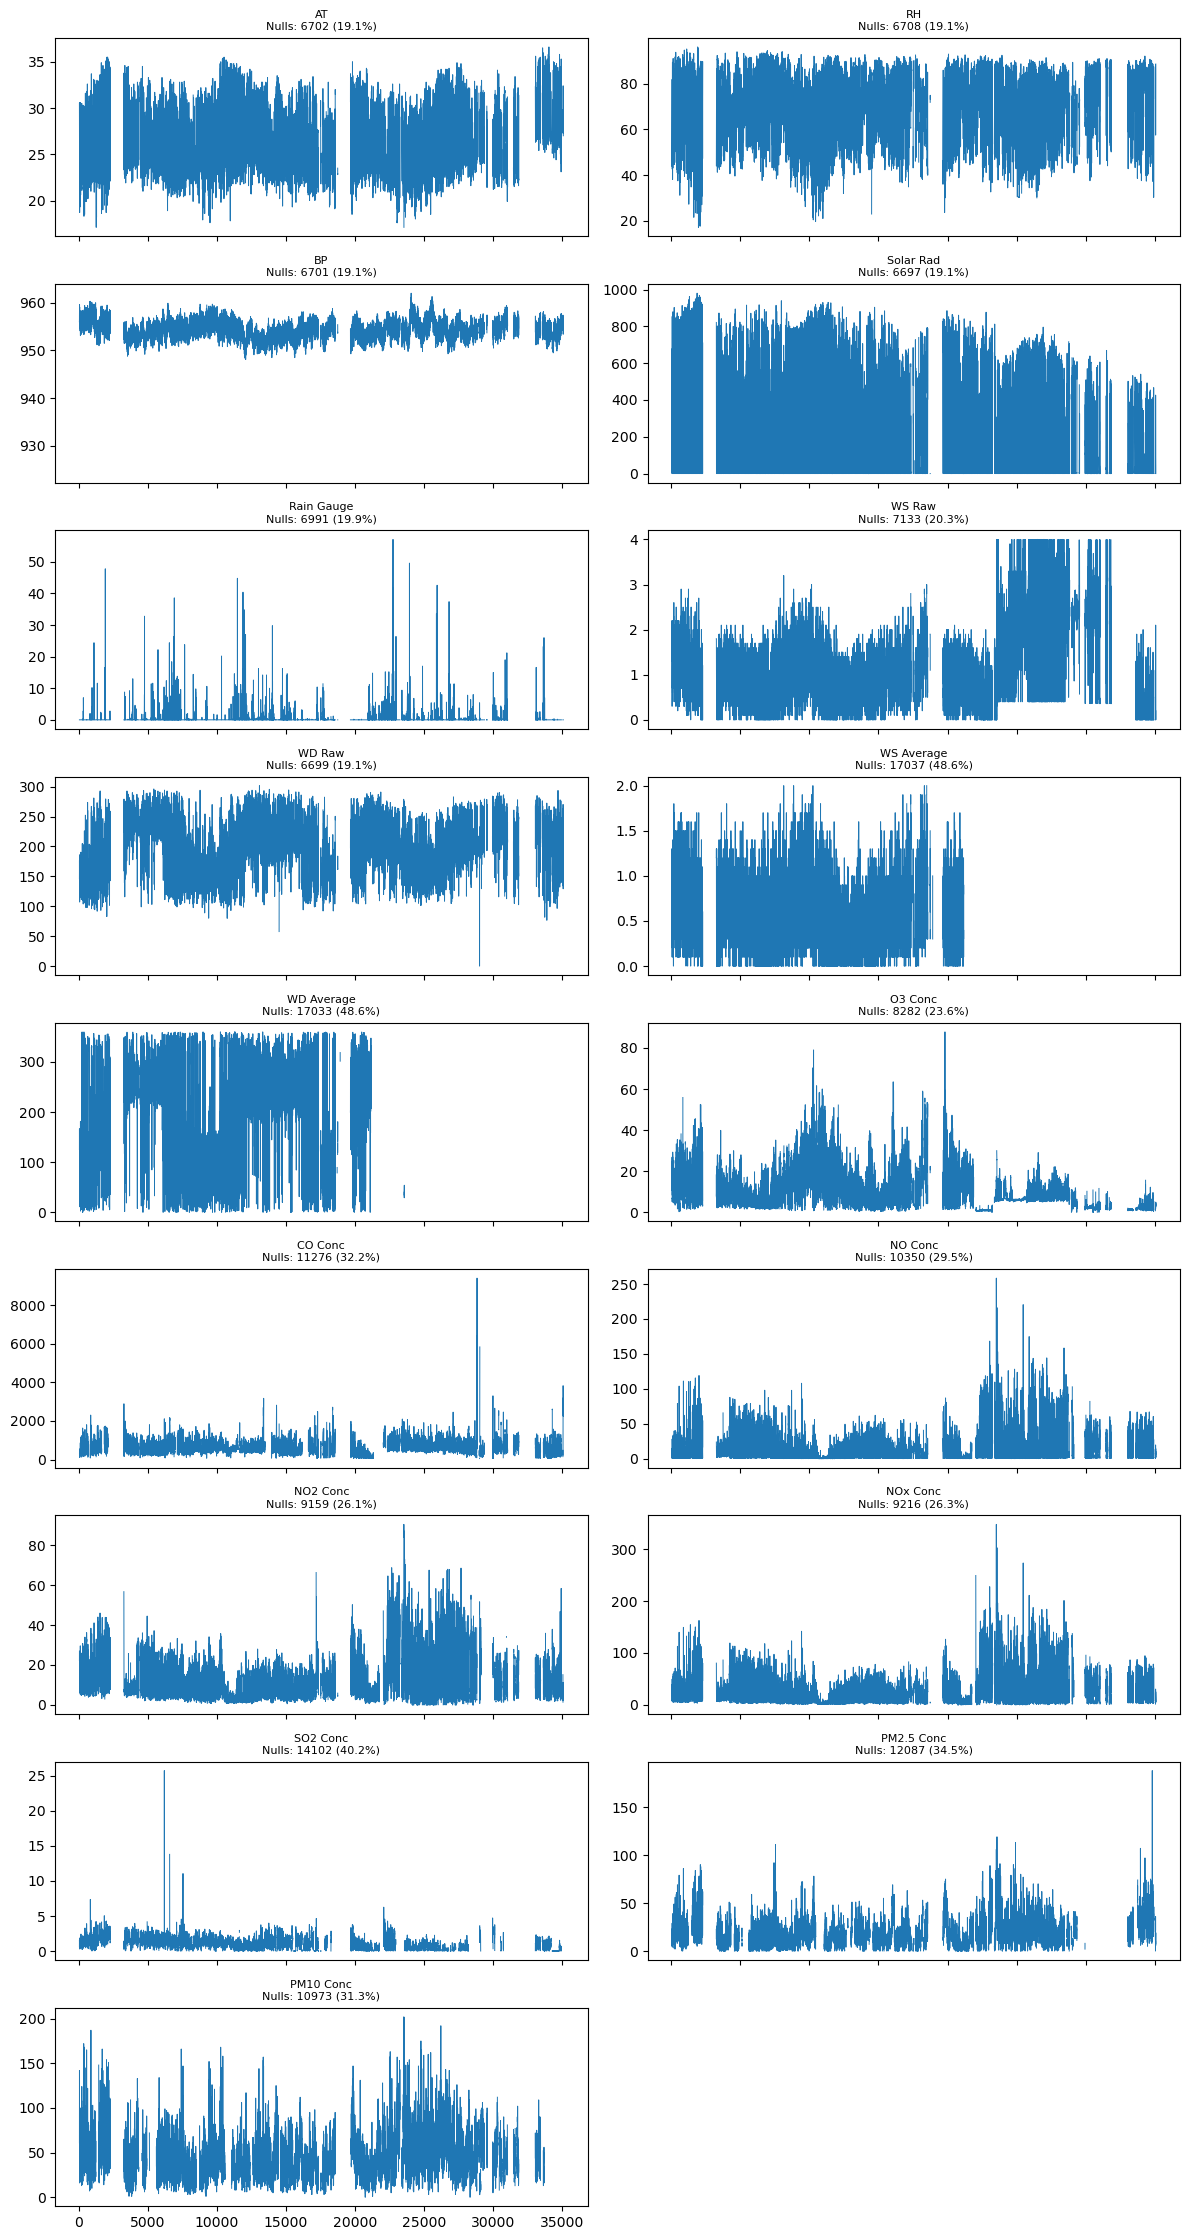

In [16]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*2.5), sharex=True)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(df_combined.index, df_combined[col], linewidth=0.7)
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

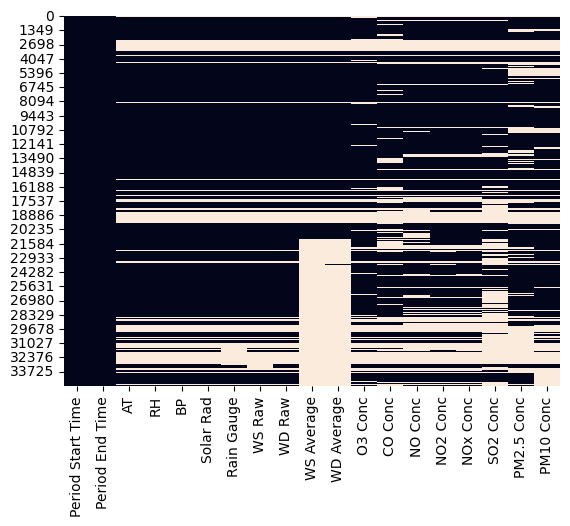

In [17]:
sns.heatmap(df_combined.isnull(), cbar=False)
plt.show()

## Conclusions

1. There is a large gap in data missing in 2021 - July to 2022 Oct. Filling this data is almost impossible. Even if we fill this, it introduces so much data. If we were to fill that data, it doesn't even have any seasonality. Instead of doing this, we should split this gap or remove that gap. We can split the data one is 2019 to 2021 June other from 2022 November to 2024. I think this is the best way to do this
2. If we do the above method, null will be reduced, then we don't need to drop those columns. I have to check before doing it
3. First 63 rows are also null it is best to drop them.

## Cheack for the all null cloumn Data Gaps

In [18]:
time_col = 'Period Start Time'
data_cols = [c for c in df_combined.columns if c != time_col and 'Time' not in c]

In [19]:
df_combined[time_col] = pd.to_datetime(df_combined[time_col])
df_combined = df_combined.sort_values(time_col).reset_index(drop=True)

In [20]:
null_mask = df_combined[data_cols].isna().all(axis=1)

In [21]:
df_combined['null_block'] = (null_mask != null_mask.shift()).cumsum()
outage_blocks = []

In [22]:
for _, block in df_combined.groupby('null_block'):
    if block[data_cols].isna().all(axis=1).any(): 
        start_time = block[time_col].iloc[0]
        end_time = block[time_col].iloc[-1]
        num_rows = len(block)
        outage_blocks.append({'Start': start_time, 'End': end_time, 'Records': num_rows})

In [23]:
outage_df = pd.DataFrame(outage_blocks)
print(outage_df)
print(f"\nTotal outage periods detected: {len(outage_df)}")

                 Start                 End  Records
0  2019-01-01 00:00:00 2019-01-03 14:00:00       63
1  2019-02-28 04:00:00 2019-02-28 04:00:00        1
2  2019-04-06 11:00:00 2019-05-17 12:00:00      986
3  2019-06-04 09:00:00 2019-06-06 15:00:00       55
4  2019-07-01 12:00:00 2019-07-05 09:00:00       94
..                 ...                 ...      ...
73 2023-11-19 21:00:00 2024-10-08 15:00:00     1195
74 2024-10-24 12:00:00 2024-10-29 15:00:00      124
75 2024-11-08 12:00:00 2024-11-10 13:00:00       50
76 2024-11-25 12:00:00 2024-11-28 12:00:00       73
77 2024-12-26 04:00:00 2024-12-30 17:00:00      110

[78 rows x 3 columns]

Total outage periods detected: 78


In [24]:
outage_df[outage_df['Records'] < 100]

,Start,End,Records
0,2019-01-01 00:00:00,2019-01-03 14:00:00,63
1,2019-02-28 04:00:00,2019-02-28 04:00:00,1
3,2019-06-04 09:00:00,2019-06-06 15:00:00,55
4,2019-07-01 12:00:00,2019-07-05 09:00:00,94
5,2019-12-07 21:00:00,2019-12-07 21:00:00,1
...,...,...,...
69,2023-11-07 01:00:00,2023-11-07 01:00:00,1
71,2023-11-15 16:00:00,2023-11-15 16:00:00,1
72,2023-11-18 17:00:00,2023-11-18 17:00:00,1
75,2024-11-08 12:00:00,2024-11-10 13:00:00,50


In [25]:
outage_df[outage_df['Records'] > 100]

,Start,End,Records
2,2019-04-06 11:00:00,2019-05-17 12:00:00,986
16,2020-12-24 10:00:00,2020-12-30 07:00:00,142
29,2021-02-12 17:00:00,2021-02-18 07:00:00,135
32,2021-02-20 05:00:00,2021-02-27 11:00:00,175
33,2021-02-27 14:00:00,2021-03-30 09:00:00,740
35,2022-11-26 11:00:00,2022-12-02 09:00:00,143
40,2023-07-17 15:00:00,2023-07-22 13:00:00,119
43,2023-08-08 13:00:00,2023-08-14 17:00:00,149
46,2023-08-16 10:00:00,2023-09-01 09:00:00,384
65,2023-10-17 04:00:00,2023-11-03 16:00:00,421


Let's remove all the data gaps that have more than 100 records (4 days)

In [26]:
for _, row in outage_df[outage_df['Records'] > 100].iterrows():
    start, end = row['Start'], row['End']
    df_combined = df_combined[~((df_combined['Period Start Time'] >= start) & (df_combined['Period Start Time'] <= end))]

In [27]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30129 entries, 0 to 35063
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30129 non-null  datetime64[ns]
 1   Period End Time    30129 non-null  datetime64[ns]
 2   AT                 28362 non-null  float64       
 3   RH                 28356 non-null  float64       
 4   BP                 28363 non-null  float64       
 5   Solar Rad          28367 non-null  float64       
 6   Rain Gauge         28073 non-null  float64       
 7   WS Raw             27931 non-null  float64       
 8   WD Raw             28365 non-null  float64       
 9   WS Average         18027 non-null  float64       
 10  WD Average         18031 non-null  float64       
 11  O3 Conc            26782 non-null  float64       
 12  CO Conc            23788 non-null  float64       
 13  NO Conc            24714 non-null  float64       
 14  NO2 Conc   

In [28]:
df_combined.describe()

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc,null_block
count,30129,30129,28362.000000,28356.000000,28363.000000,28367.000000,28073.000000,27931.000000,28365.000000,18027.000000,18031.000000,26782.000000,23788.000000,24714.00000,25905.000000,25848.000000,20962.000000,22977.000000,24091.000000,30129.000000
mean,2021-05-20 10:36:24.492870656,2021-05-20 11:36:24.446878464,25.861723,71.360957,954.454367,160.941920,0.178948,1.113508,196.592843,0.512215,195.797665,11.388677,652.752145,14.83218,13.030843,27.218068,1.255160,17.380859,43.971151,45.680042
min,2019-01-01 00:00:00,2019-01-01 01:00:00,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.157000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2019-12-21 22:00:00,2019-12-21 23:00:00,23.200000,61.140000,953.100000,0.160000,0.000000,0.400000,162.100000,0.200000,121.450000,4.910000,455.717500,2.21000,5.900000,8.120000,0.640000,8.000000,28.000000,14.000000
50%,2020-10-30 18:00:00,2020-10-30 19:00:00,25.000000,74.700000,954.400000,4.240000,0.000000,1.000000,201.200000,0.400000,208.300000,8.480000,614.900000,8.89000,11.030000,20.645000,1.180000,15.000000,40.000000,20.000000
75%,2023-02-04 05:00:00,2023-02-04 06:00:00,28.300000,83.222500,955.800000,281.750000,0.000000,1.600000,227.000000,0.700000,279.400000,15.570000,790.815000,21.20000,17.280000,37.521750,1.780000,23.000000,56.000000,74.000000
max,2024-12-31 23:00:00,2025-01-01 00:00:00,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,2.000000,360.000000,87.800000,9401.800000,258.45000,90.470000,348.300000,25.760000,188.000000,202.000000,156.000000
std,NaN,NaN,3.396117,14.553382,1.927623,237.078795,1.418530,0.861965,40.250626,0.364607,94.126721,9.545026,338.926538,17.61073,9.642111,25.424862,0.833361,12.506621,22.575014,41.896002


<function matplotlib.pyplot.show(close=None, block=None)>

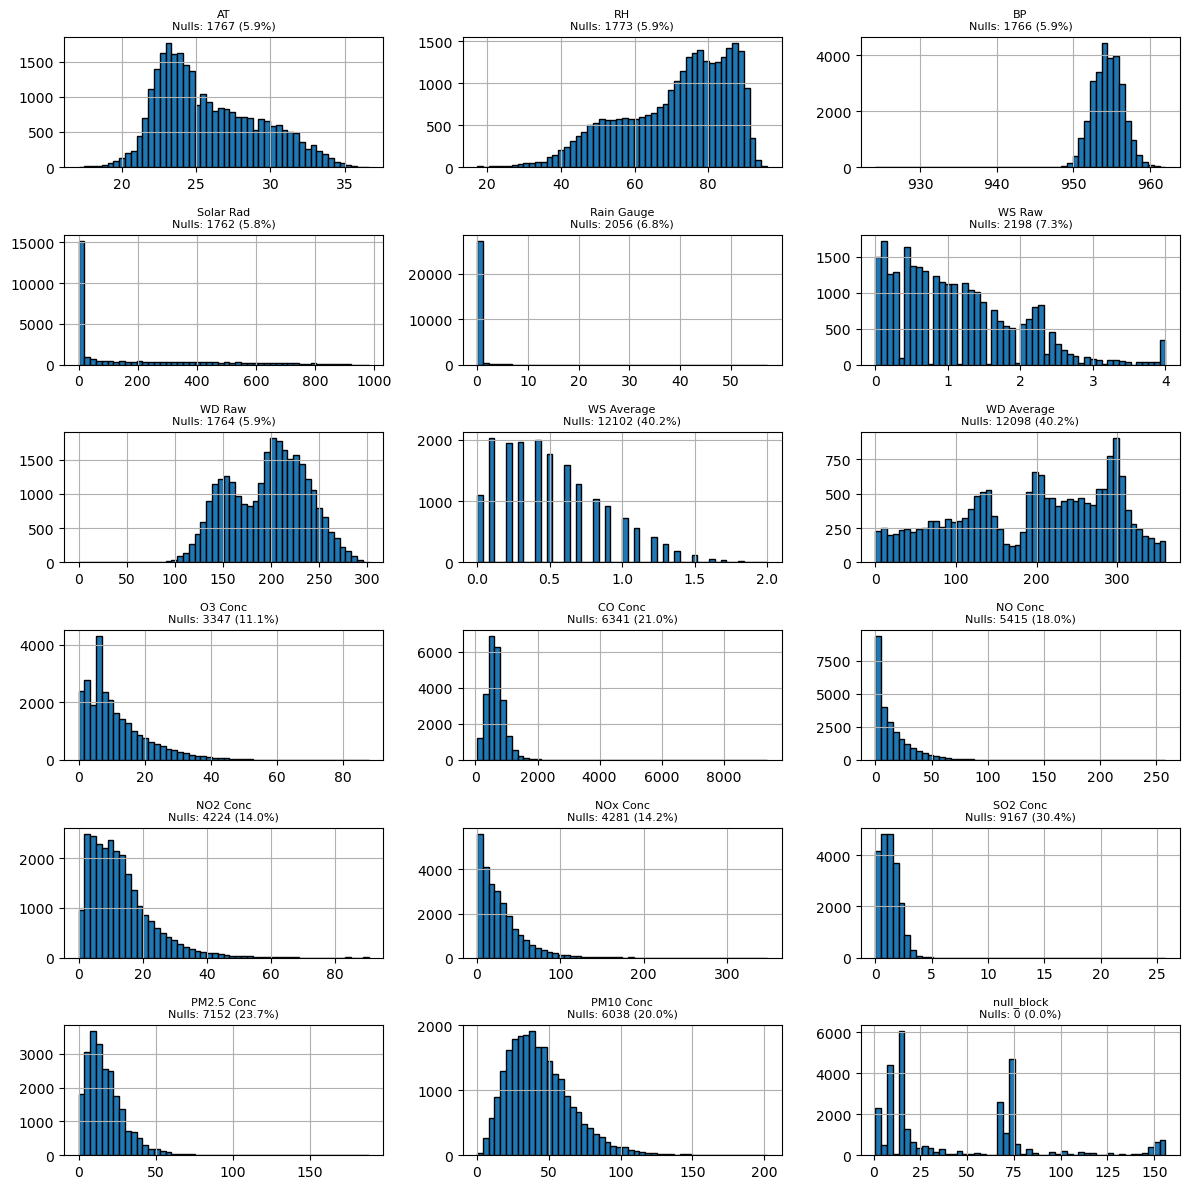

In [29]:
numeric_cols = [col for col in df_combined.columns if pd.api.types.is_numeric_dtype(df_combined[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_combined[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_combined[col].isna().sum()} ({df_combined[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

1. We don't need WS Average & WD Average because WS Raw & WD Raw columns are showing the same thing.

There is a large gap of the data missing showing on the belows graph. It is not actual data missing it happened because we removed the large gap from 2021-07 to 2022-10. So what this graph does is continue the time correctly but there is no data in that period. It connects the last data point with a line

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9280\3663450081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3_time['Date'] = df_o3_time['Period Start Time'].dt.date


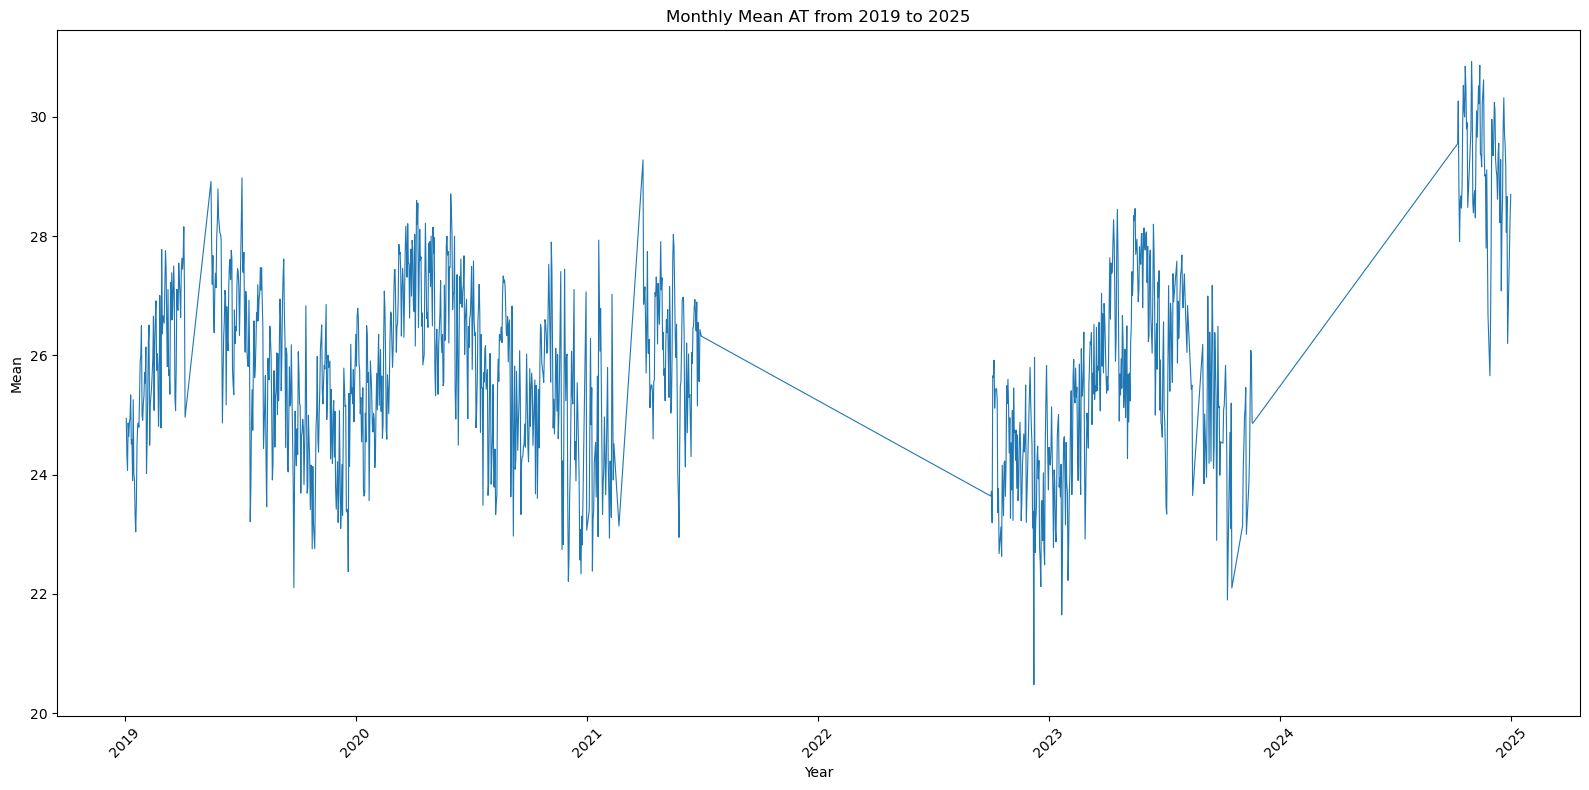

In [30]:
df_o3_time = df_combined[['Period Start Time','AT']]

df_o3_time['Date'] = df_o3_time['Period Start Time'].dt.date

df_filtered = df_o3_time[(df_o3_time['Period Start Time'].dt.year >= 2019) &
                         (df_o3_time['Period Start Time'].dt.year <= 2024)]

daily_at = df_filtered.groupby('Date')['AT'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(x='Date', y='AT', data=daily_at, linewidth=0.8)
plt.title('Monthly Mean AT from 2019 to 2025')
plt.xlabel('Year')
plt.ylabel('Mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Dropping first 63 rows

In [31]:
df_combined.head(3)

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc,null_block
0,2019-01-01 00:00:00,2019-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2019-01-01 01:00:00,2019-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2019-01-01 02:00:00,2019-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [32]:
start_remove = '2019-01-01 00:00:00'
end_remove   = '2019-01-03 14:00:00'

In [33]:
df_combined = df_combined[~((df_combined['Period Start Time'] >= start_remove) & (df_combined['Period Start Time'] <= end_remove))].reset_index(drop=True)

In [34]:
df_combined.head(3)

,Period Start Time,Period End Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,WS Average,WD Average,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc,null_block
0,2019-01-03 15:00:00,2019-01-03 16:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,0.9,125.3,13.44,NaN,NaN,NaN,NaN,0.60,NaN,NaN,2
1,2019-01-03 16:00:00,2019-01-03 17:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,0.7,131.6,15.73,109.0,12.81,22.20,35.01,1.34,NaN,61.0,2
2,2019-01-03 17:00:00,2019-01-03 18:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,1.3,148.6,17.42,NaN,10.90,19.22,30.12,1.56,5.0,43.0,2


### Dropping the large null value columns

We don't need to drop any column in here apart from some useless columns to drop
- WS Average
- WD Average
 * Also the null block column we don't need that anymore
 * We don't need Period End Time we can see that time stamp using Period Start Time

In [35]:
df_combined2 = df_combined.drop([ 'WS Average', 'WD Average', 'null_block', 'Period End Time'], axis=1)

In [36]:
df_combined3 = df_combined2.reset_index(drop=True)
df_combined3

,Period Start Time,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
0,2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,NaN,NaN,NaN,NaN,0.60,NaN,NaN
1,2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.0,12.810,22.200,35.010,1.34,NaN,61.0
2,2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,NaN,10.900,19.220,30.120,1.56,5.0,43.0
3,2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,NaN,11.950,23.700,35.660,1.25,12.0,42.0
4,2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.0,12.370,26.980,39.350,1.35,23.0,142.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30061,2024-12-31 19:00:00,27.9,80.80,955.6,0.10,0.0,0.5,178.2,3.96,2823.0,5.162,7.413,12.576,NaN,13.0,NaN
30062,2024-12-31 20:00:00,27.4,84.80,956.0,0.10,0.0,0.1,240.7,2.54,3000.1,10.521,10.870,21.386,NaN,16.0,NaN
30063,2024-12-31 21:00:00,27.3,85.70,956.9,0.10,0.0,0.1,264.0,2.90,2727.4,7.410,6.929,14.336,NaN,19.0,NaN
30064,2024-12-31 22:00:00,27.2,87.50,957.0,0.10,0.0,0.0,200.0,3.35,2532.0,4.460,6.030,10.489,NaN,10.0,NaN


In [37]:
df_combined3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30066 non-null  datetime64[ns]
 1   AT                 28362 non-null  float64       
 2   RH                 28356 non-null  float64       
 3   BP                 28363 non-null  float64       
 4   Solar Rad          28367 non-null  float64       
 5   Rain Gauge         28073 non-null  float64       
 6   WS Raw             27931 non-null  float64       
 7   WD Raw             28365 non-null  float64       
 8   O3 Conc            26782 non-null  float64       
 9   CO Conc            23788 non-null  float64       
 10  NO Conc            24714 non-null  float64       
 11  NO2 Conc           25905 non-null  float64       
 12  NOx Conc           25848 non-null  float64       
 13  SO2 Conc           20962 non-null  float64       
 14  PM2.5 

### Null Map

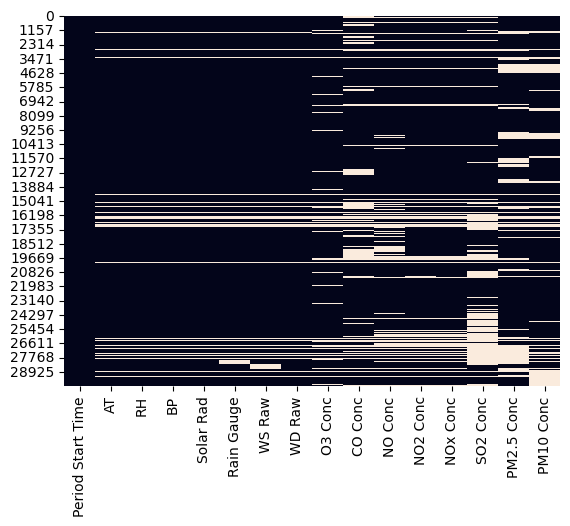

In [38]:
sns.heatmap(df_combined3.isnull(), cbar=False)
plt.show()

### Correlation heatmap

In [39]:
corr_columns = ['AT', 'RH', 'BP', 'Solar Rad',
       'Rain Gauge', 'WD Raw', 'O3 Conc', 'NO Conc', 'NO2 Conc',
       'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
corr_df = df_combined3[corr_columns]

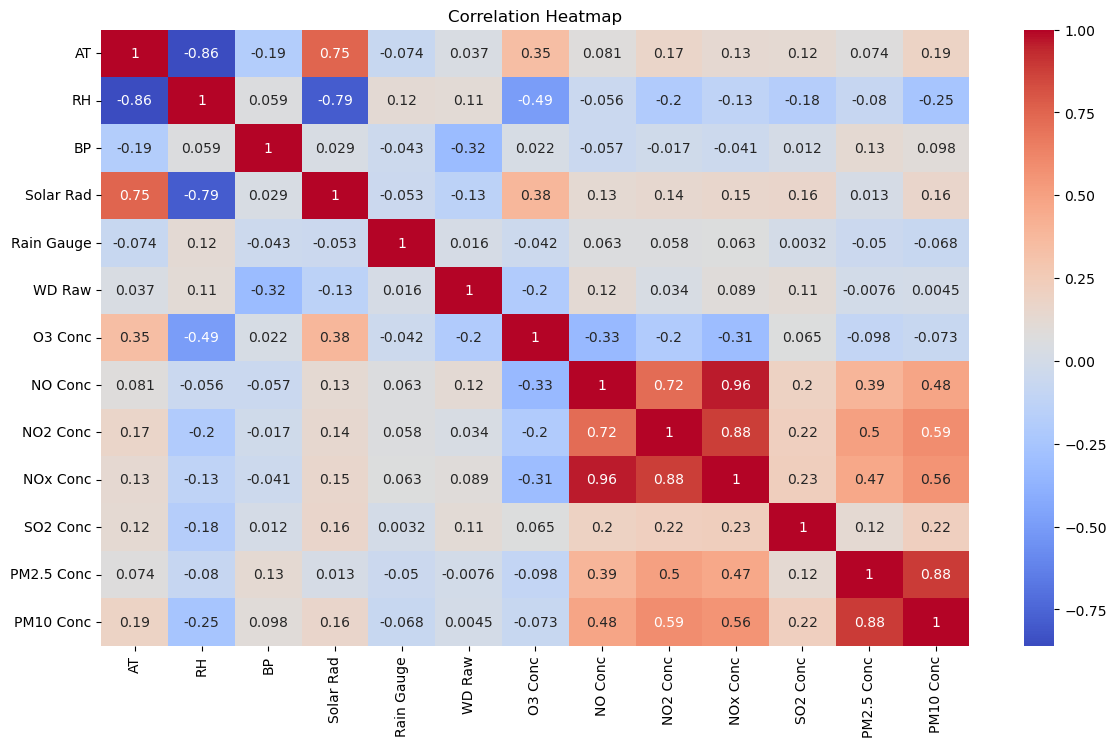

In [40]:
corr = corr_df.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Null threatment

### Fowardfill Method

* Fill the small gaps with time forward fill.
* This is only possible because usually data (pollutant and weather) do not change within the same close hours. Likely the same as the hour before.
* There for we can fill the small gap with 3 hour limit.

In [41]:
df_filled = df_combined3.ffill(limit=5)

In [42]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Period Start Time  30066 non-null  datetime64[ns]
 1   AT                 28603 non-null  float64       
 2   RH                 28607 non-null  float64       
 3   BP                 28607 non-null  float64       
 4   Solar Rad          28607 non-null  float64       
 5   Rain Gauge         28312 non-null  float64       
 6   WS Raw             28176 non-null  float64       
 7   WD Raw             28607 non-null  float64       
 8   O3 Conc            28217 non-null  float64       
 9   CO Conc            25472 non-null  float64       
 10  NO Conc            27126 non-null  float64       
 11  NO2 Conc           27482 non-null  float64       
 12  NOx Conc           27499 non-null  float64       
 13  SO2 Conc           23194 non-null  float64       
 14  PM2.5 

<function matplotlib.pyplot.show(close=None, block=None)>

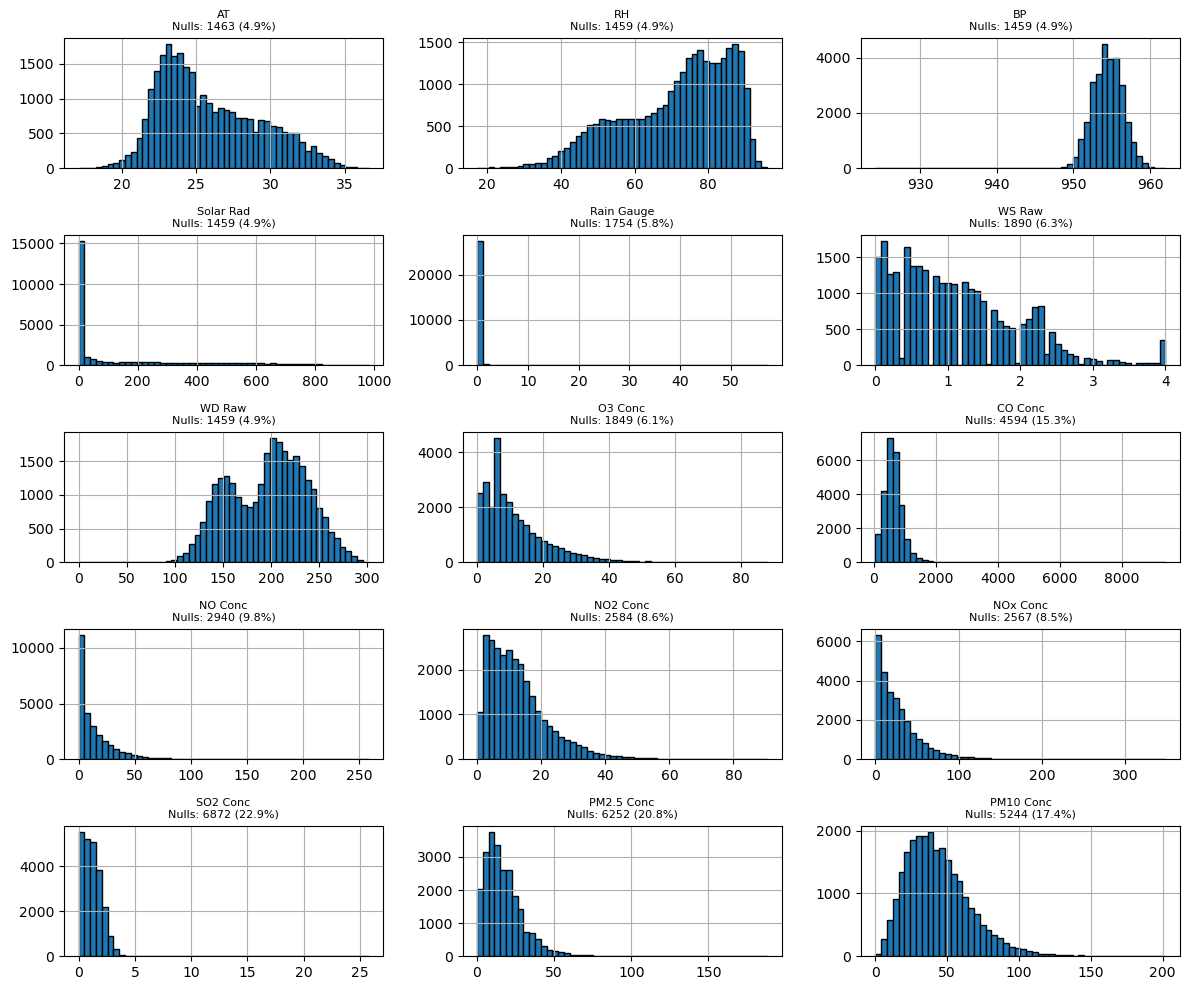

In [43]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

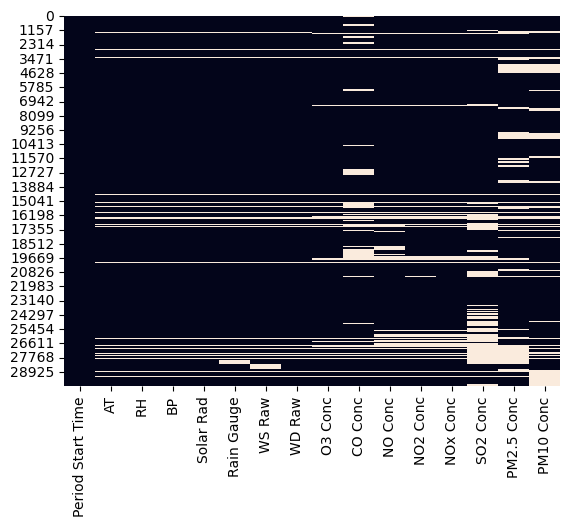

In [44]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

### Interpolate using Time

After filling the tiny gaps, we still have larger ones. For many of your variables, a simple time-based interpolation is the best way to fill them.

* Method: Linear or Time Interpolation

* Why: It assumes a smooth, gradual change between two known points (e.g., the temperature didn't teleport; it rose or fell steadily). This is a very strong assumption for environmental data.

In [45]:
if df_filled.index.name != 'Period Start Time':
    df_filled = df_filled.set_index('Period Start Time')

In [46]:
cols_to_interpolate = ['RH', 'BP', 'Solar Rad', 'Rain Gauge', 'WD Raw', 'WS Raw']
df_filled[cols_to_interpolate] = df_filled[cols_to_interpolate].interpolate(method='time')

In [47]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30066 entries, 2019-01-03 15:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AT          28603 non-null  float64
 1   RH          30066 non-null  float64
 2   BP          30066 non-null  float64
 3   Solar Rad   30066 non-null  float64
 4   Rain Gauge  30066 non-null  float64
 5   WS Raw      30066 non-null  float64
 6   WD Raw      30066 non-null  float64
 7   O3 Conc     28217 non-null  float64
 8   CO Conc     25472 non-null  float64
 9   NO Conc     27126 non-null  float64
 10  NO2 Conc    27482 non-null  float64
 11  NOx Conc    27499 non-null  float64
 12  SO2 Conc    23194 non-null  float64
 13  PM2.5 Conc  23814 non-null  float64
 14  PM10 Conc   24822 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [48]:
df_filled

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
Period Start Time,,,,,,,,,,,,,,,
2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,NaN,NaN,NaN,NaN,0.60,NaN,NaN
2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.0,12.810,22.200,35.010,1.34,NaN,61.0
2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.0,10.900,19.220,30.120,1.56,5.0,43.0
2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.0,11.950,23.700,35.660,1.25,12.0,42.0
2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.0,12.370,26.980,39.350,1.35,23.0,142.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,27.9,80.80,955.6,0.10,0.0,0.5,178.2,3.96,2823.0,5.162,7.413,12.576,NaN,13.0,NaN
2024-12-31 20:00:00,27.4,84.80,956.0,0.10,0.0,0.1,240.7,2.54,3000.1,10.521,10.870,21.386,NaN,16.0,NaN
2024-12-31 21:00:00,27.3,85.70,956.9,0.10,0.0,0.1,264.0,2.90,2727.4,7.410,6.929,14.336,NaN,19.0,NaN


In [49]:
df_filled.isnull().sum()

AT            1463
RH               0
BP               0
Solar Rad        0
Rain Gauge       0
WS Raw           0
WD Raw           0
O3 Conc       1849
CO Conc       4594
NO Conc       2940
NO2 Conc      2584
NOx Conc      2567
SO2 Conc      6872
PM2.5 Conc    6252
PM10 Conc     5244
dtype: int64

In [50]:
df_filled

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
Period Start Time,,,,,,,,,,,,,,,
2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,NaN,NaN,NaN,NaN,0.60,NaN,NaN
2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.0,12.810,22.200,35.010,1.34,NaN,61.0
2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.0,10.900,19.220,30.120,1.56,5.0,43.0
2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.0,11.950,23.700,35.660,1.25,12.0,42.0
2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.0,12.370,26.980,39.350,1.35,23.0,142.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,27.9,80.80,955.6,0.10,0.0,0.5,178.2,3.96,2823.0,5.162,7.413,12.576,NaN,13.0,NaN
2024-12-31 20:00:00,27.4,84.80,956.0,0.10,0.0,0.1,240.7,2.54,3000.1,10.521,10.870,21.386,NaN,16.0,NaN
2024-12-31 21:00:00,27.3,85.70,956.9,0.10,0.0,0.1,264.0,2.90,2727.4,7.410,6.929,14.336,NaN,19.0,NaN


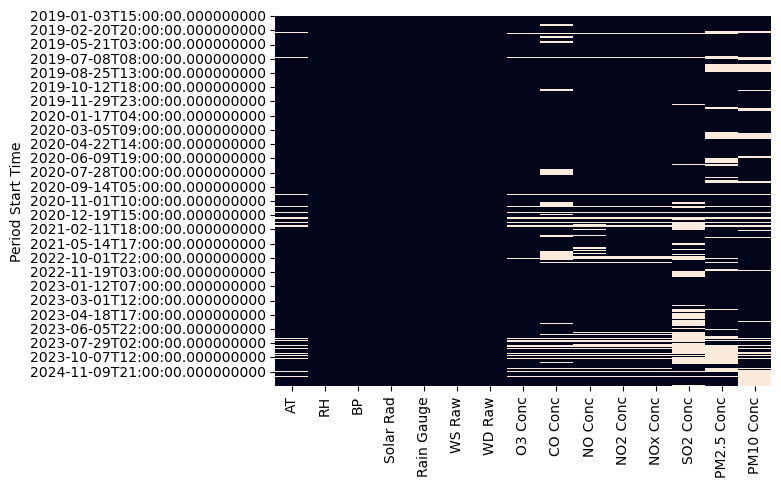

In [51]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

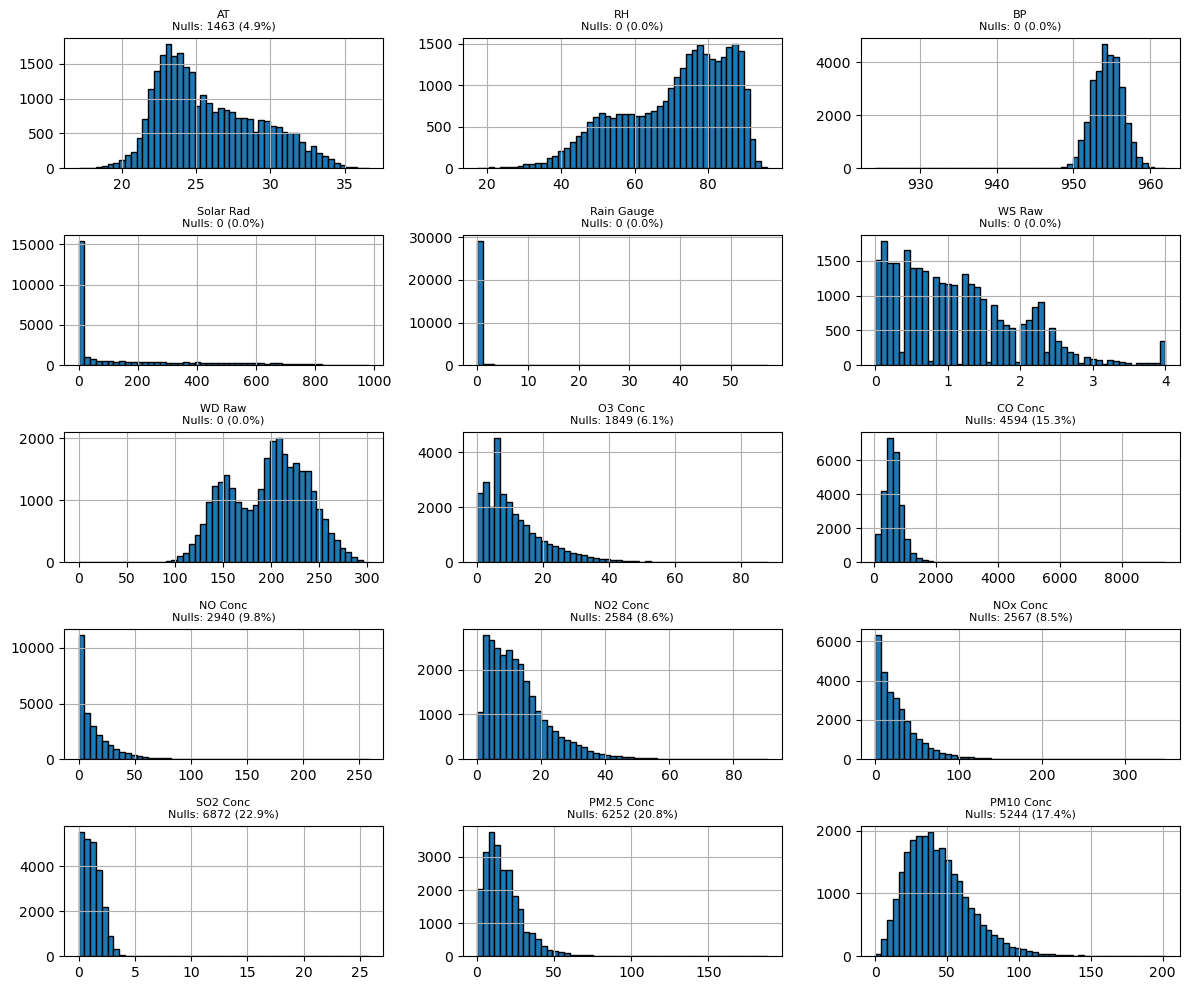

In [52]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

### Multivariate Imputation (MICE)

* These are the columns that have large missing blocks (AT, O3, PM2.5, PM10) or are highly correlated with that block (Solar Rad, NO, NO2, NOx, SO2).
* We will use IterativeImputer (MICE) to build a model that uses all these columns to predict and fill the gaps in each other. This will capture the complex relationships shown in the heatmap (like AT vs. RH, PM2.5 vs. PM10, and O3 vs. Solar Rad)
- Also this one could be a novel thing

In [53]:
complex_cols = [
    'AT',
    'Solar Rad',
    'O3 Conc',
    'CO Conc',
    'NO Conc',
    'NO2 Conc',
    'NOx Conc',
    'SO2 Conc',
    'PM2.5 Conc',
    'PM10 Conc'
]

In [54]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=0, min_value=0.0)
df_filled[complex_cols] = imputer.fit_transform(df_filled[complex_cols])

In [55]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30066 entries, 2019-01-03 15:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AT          30066 non-null  float64
 1   RH          30066 non-null  float64
 2   BP          30066 non-null  float64
 3   Solar Rad   30066 non-null  float64
 4   Rain Gauge  30066 non-null  float64
 5   WS Raw      30066 non-null  float64
 6   WD Raw      30066 non-null  float64
 7   O3 Conc     30066 non-null  float64
 8   CO Conc     30066 non-null  float64
 9   NO Conc     30066 non-null  float64
 10  NO2 Conc    30066 non-null  float64
 11  NOx Conc    30066 non-null  float64
 12  SO2 Conc    30066 non-null  float64
 13  PM2.5 Conc  30066 non-null  float64
 14  PM10 Conc   30066 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [56]:
df_filled.isnull().sum()

AT            0
RH            0
BP            0
Solar Rad     0
Rain Gauge    0
WS Raw        0
WD Raw        0
O3 Conc       0
CO Conc       0
NO Conc       0
NO2 Conc      0
NOx Conc      0
SO2 Conc      0
PM2.5 Conc    0
PM10 Conc     0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

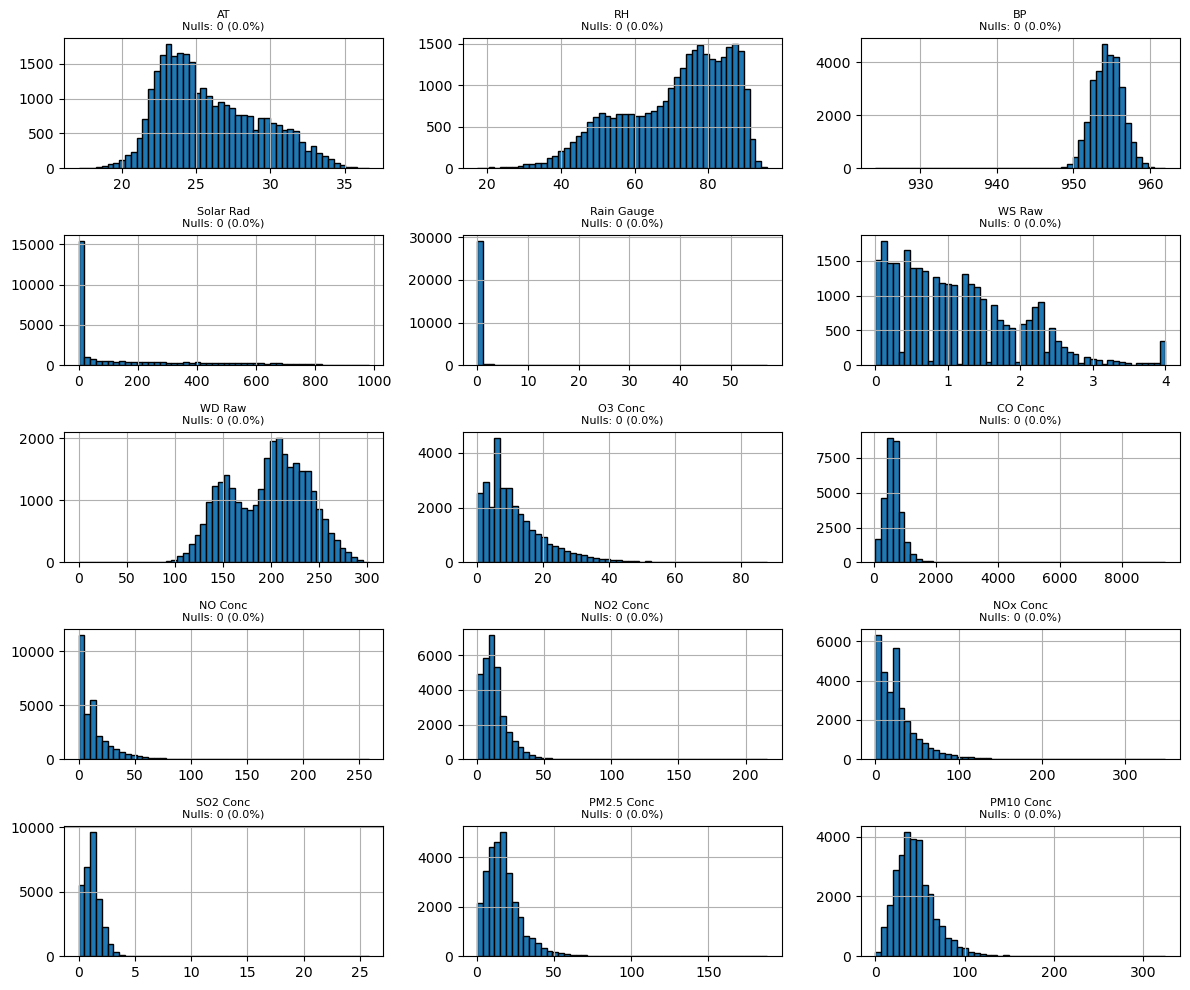

In [57]:
numeric_cols = [col for col in df_filled.columns if pd.api.types.is_numeric_dtype(df_filled[col])]

n_cols = 3 
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2))
axes = axes.flatten() 

for i, col in enumerate(numeric_cols):
    df_filled[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(f"{col}\nNulls: {df_filled[col].isna().sum()} ({df_filled[col].isna().mean()*100:.1f}%)", fontsize=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

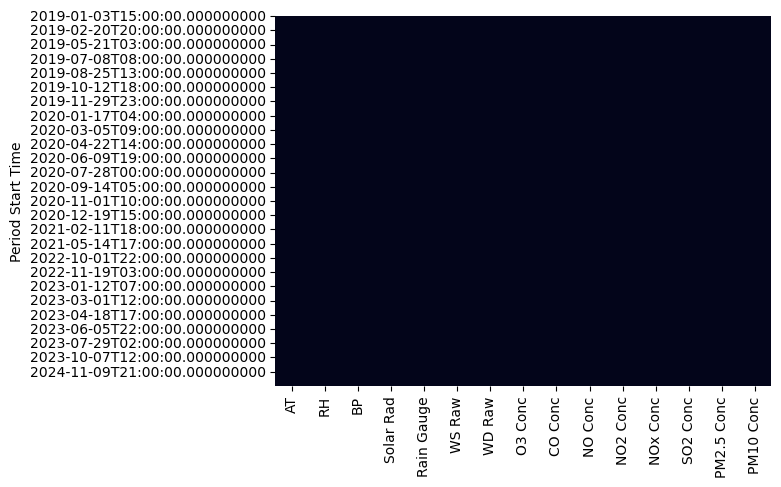

In [58]:
sns.heatmap(df_filled.isnull(), cbar=False)
plt.show()

In [59]:
df_filled.describe()

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.00000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000
mean,25.913497,71.071717,954.422928,166.091174,0.178251,1.128142,196.564550,11.42685,634.615977,14.072506,12.911022,26.923524,1.196529,17.023671,44.988521
std,3.357941,14.502207,1.974343,237.047341,1.378443,0.863429,40.295472,9.27585,325.307788,16.909667,9.346772,24.617106,0.747959,11.471591,21.979299
min,17.100000,17.220000,924.200000,0.020000,0.000000,0.000000,0.000000,0.00000,50.157000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.300000,60.492500,953.100000,0.160000,0.000000,0.400000,161.600000,5.28000,452.940000,1.870000,6.140000,8.522500,0.720000,9.000000,30.000000
50%,25.100000,74.350000,954.400000,13.620000,0.000000,1.000000,201.500000,8.94000,609.541201,9.420000,11.890000,22.670000,1.150000,16.000000,43.000000
75%,28.307542,82.897500,955.700000,291.860000,0.000000,1.700000,227.400000,15.43000,758.647500,18.470000,16.390000,35.210000,1.587605,22.000000,56.000000
max,36.600000,95.970000,962.000000,980.190000,57.100000,4.000000,301.700000,87.80000,9401.800000,258.450000,215.976048,348.300000,25.760000,188.000000,325.078725


## Correlation Cheak

In [60]:
corr_columns = ['AT', 'RH', 'BP', 'Solar Rad',
       'Rain Gauge', 'WD Raw', 'O3 Conc', 'NO Conc', 'NO2 Conc',
       'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
corr_df = df_filled[corr_columns]

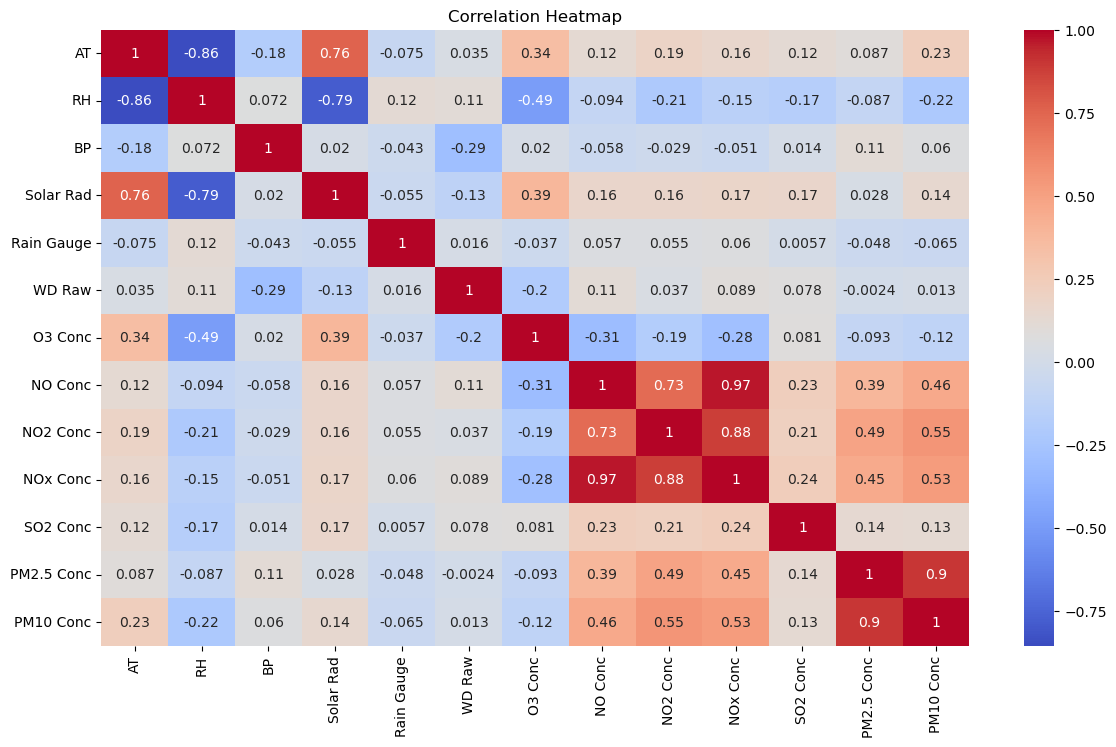

In [61]:
corr = corr_df.corr()
plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [62]:
columns_to_describe = ['O3 Conc','CO Conc', 'NO Conc', 'NO2 Conc', 'NOx Conc', 'SO2 Conc', 'PM2.5 Conc', 'PM10 Conc']
summary_stats = df_filled[columns_to_describe].describe()
summary_stats

,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
count,30066.00000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000,30066.000000
mean,11.42685,634.615977,14.072506,12.911022,26.923524,1.196529,17.023671,44.988521
std,9.27585,325.307788,16.909667,9.346772,24.617106,0.747959,11.471591,21.979299
min,0.00000,50.157000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.28000,452.940000,1.870000,6.140000,8.522500,0.720000,9.000000,30.000000
50%,8.94000,609.541201,9.420000,11.890000,22.670000,1.150000,16.000000,43.000000
75%,15.43000,758.647500,18.470000,16.390000,35.210000,1.587605,22.000000,56.000000
max,87.80000,9401.800000,258.450000,215.976048,348.300000,25.760000,188.000000,325.078725


In [63]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30066 entries, 2019-01-03 15:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AT          30066 non-null  float64
 1   RH          30066 non-null  float64
 2   BP          30066 non-null  float64
 3   Solar Rad   30066 non-null  float64
 4   Rain Gauge  30066 non-null  float64
 5   WS Raw      30066 non-null  float64
 6   WD Raw      30066 non-null  float64
 7   O3 Conc     30066 non-null  float64
 8   CO Conc     30066 non-null  float64
 9   NO Conc     30066 non-null  float64
 10  NO2 Conc    30066 non-null  float64
 11  NOx Conc    30066 non-null  float64
 12  SO2 Conc    30066 non-null  float64
 13  PM2.5 Conc  30066 non-null  float64
 14  PM10 Conc   30066 non-null  float64
dtypes: float64(15)
memory usage: 3.7 MB


In [64]:
df_filled.head(5)

,AT,RH,BP,Solar Rad,Rain Gauge,WS Raw,WD Raw,O3 Conc,CO Conc,NO Conc,NO2 Conc,NOx Conc,SO2 Conc,PM2.5 Conc,PM10 Conc
Period Start Time,,,,,,,,,,,,,,,
2019-01-03 15:00:00,30.5,43.87,956.0,677.49,0.0,1.7,146.1,13.44,550.926096,14.412209,13.008813,27.364692,0.60,15.236582,47.696954
2019-01-03 16:00:00,29.8,47.90,956.0,497.63,0.0,1.7,148.1,15.73,109.000000,12.810000,22.200000,35.010000,1.34,22.206909,61.000000
2019-01-03 17:00:00,27.1,55.75,956.2,162.28,0.0,2.2,156.8,17.42,109.000000,10.900000,19.220000,30.120000,1.56,5.000000,43.000000
2019-01-03 18:00:00,25.2,61.64,956.8,22.60,0.0,1.6,176.9,13.03,109.000000,11.950000,23.700000,35.660000,1.25,12.000000,42.000000
2019-01-03 19:00:00,24.0,67.95,957.6,0.97,0.0,1.3,175.2,10.57,290.000000,12.370000,26.980000,39.350000,1.35,23.000000,142.000000


In [65]:
df_filled.to_csv("Kandy_data_cleaned.csv")